
# Bayesian model selection

An overview of Bayesian model selection combining gammapy with ultranest and arziv packages. 


## Context

For a general overview see:
- https://arviz-devs.github.io/EABM/Chapters/Model_comparison.html
- https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html

Here we are going to focus on the following questions:
- What are the comon information criterion used for model selection nowadays  ?
- how the parameter posterior is sensitive to the choice of prior ?
- how model comparison is sensitive to the choice of prior ?


## Proposed approach

In this example, we will perform a Bayesian analysis with multiple models the RXJ1713 data.

## Setup

As usual, we’ll start with some setup …




In [1]:
# imports
from gammapy.datasets import Datasets

from gammapy.modeling.models import (
    UniformPrior,
    LogUniformPrior,
)
import arviz as az
from gammapy.modeling.sampler import Sampler

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Loading the dataset


In [2]:
datasets_3d = Datasets.read(
    "datasets_3d_hess_rjj1713_.yaml", "models_3d_hess_rjj1713_.yaml"
)
models_template = datasets_3d.models

datasets_3d = Datasets([d.downsample(factor=5) for d in datasets_3d])
# TODO: compare how the parameters and the elpd and elpd_err diffs are affected by the downsampling of the dataset
# try  factor = 1,2,5,10,25

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
HDU 'MASK_FIT' not found


In [3]:
import astropy.units as u

for d in datasets_3d:
    d.mask_fit = d.mask.geom.boundary_mask((0.5 * u.deg, 1 * u.deg))
# (d.counts*d.mask_fit).plot_interactive()

## Defining the models and prior

In [4]:
models_template["RXJ1713"].parameters.to_table()

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,amplitude,2.0565e-17,MeV-1 s-1 cm-2,1.075e-18,nan,nan,False,,
,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,
,alpha,1.7770e+00,,9.446e-02,nan,nan,False,,
,beta,2.0921e-01,,4.798e-02,nan,nan,False,,
,lon_0,2.5839e+02,deg,0.000e+00,nan,nan,True,,
,lat_0,-3.9762e+01,deg,0.000e+00,-9.000e+01,9.000e+01,True,,


In [5]:
models_template["RXJ1713"].position.galactic

<SkyCoord (Galactic): (l, b) in deg
    (347.33283615, -0.47272957)>

In [6]:
from gammapy.modeling.models import Shell2SpatialModel, GeneralizedGaussianSpatialModel

models_template.freeze()
models_template["RXJ1713"].unfreeze("spectral")
models_template["RXJ1713"].spectral_model.amplitude.prior = LogUniformPrior(
    min=8e-18, max=5e-16
)
models_template["RXJ1713"].spectral_model.alpha.prior = UniformPrior(min=1.5, max=2.5)
models_template["RXJ1713"].spectral_model.beta.prior = UniformPrior(min=0, max=0.5)

pos = models_template["RXJ1713"].position.galactic
models_shell = models_template.copy()
models_shell["RXJ1713"].spatial_model = Shell2SpatialModel(
    lon_0=pos.l, lat_0=pos.b, r_0=0.5 * u.deg, eta=0.5, frame="galactic"
)
models_shell["RXJ1713"].spatial_model.lon_0.prior = UniformPrior(
    min=pos.l.value - 0.3, max=pos.l.value + 0.3
)
models_shell["RXJ1713"].spatial_model.lat_0.prior = UniformPrior(
    min=pos.b.value - 0.3, max=pos.b.value + 0.3
)
models_shell["RXJ1713"].spatial_model.r_0.prior = UniformPrior(min=0.2, max=0.9)
models_shell["RXJ1713"].spatial_model.eta.prior = UniformPrior(min=0.1, max=0.7)

models_disk = models_template.copy()
models_disk["RXJ1713"].spatial_model = GeneralizedGaussianSpatialModel(
    lon_0=pos.l, lat_0=pos.b, r_0=0.5 * u.deg, eta=0.1, frame="galactic"
)
models_disk["RXJ1713"].spatial_model.lon_0.prior = UniformPrior(
    min=pos.l.value - 0.3, max=pos.l.value + 0.3
)
models_disk["RXJ1713"].spatial_model.lat_0.prior = UniformPrior(
    min=pos.b.value - 0.3, max=pos.b.value + 0.3
)
models_disk["RXJ1713"].spatial_model.r_0.prior = UniformPrior(min=0.1, max=0.7)
models_disk["RXJ1713"].spatial_model.eta.frozen = True

alternative_models_3d = {
    "fermi-template": models_template,
    "disk": models_disk,
    "shell": models_shell,
}

## Running the Bayesian model selection

Let's define a sample few `live_points` and a large `frac_remain` so it's faster (3d is more time consunming because the models have to be convolved by the PSF)

In [7]:
sampler_opts_3d = {
    "live_points": 200,
    "frac_remain": 0.3,
    "log_dir": None,
}
sampler_3d = Sampler(sampler_opts=sampler_opts_3d)

and run the bayesian model selection

In [8]:
from gammapy.modeling.selection import BayesianModelSelection

bms_3d = BayesianModelSelection(
    sampler_3d, prosterior_reduction_factor=4, n_prior_samples=None
)

bms_results_3d = bms_3d.run(datasets_3d, alternative_models_3d)

Evaluating fermi-template


Model HESS J1708-410 is outside the target geom but contributes inside through the psf.This contribution cannot be estimated precisely.Consider extending the dataset geom and/or the masked margin in the mask_fit.
Model HESS J1718-385 is outside the target geom but contributes inside through the psf.This contribution cannot be estimated precisely.Consider extending the dataset geom and/or the masked margin in the mask_fit.


[ultranest] Sampling 200 live points from prior ...


[ultranest] Explored until L=5e+03  5.33 [5304.6082..5304.6116]*| it/evals=1540/3137 eff=52.4345% N=200 0 
[ultranest] Likelihood function evaluations: 3153
[ultranest]   logZ = 5298 +- 0.1306
[ultranest] Effective samples strategy satisfied (ESS = 719.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.29, need <0.5)
[ultranest]   logZ error budget: single: 0.16 bs:0.13 tail:0.26 total:0.29 required:<0.50
[ultranest] done iterating.

logZ = 5298.387 +- 0.353
  single instance: logZ = 5298.387 +- 0.165
  bootstrapped   : logZ = 5298.373 +- 0.236
  tail           : logZ = +- 0.262
insert order U test : converged: True correlation: inf iterations

    amplitude           : 0.0000000000000000182│ ▁▁▁▁▁▁▁▂▃▂▄▅▆▆▄▇▇▆▆▄▄▃▃▂▂▂▁▁ ▁▁▁▁▁  ▁ │0.0000000000000000262    0.0000000000000000217 +- 0.0000000000000000010
    alpha               : 1.500 │▁▁▁▁▁▁▂▁▁▂▂▃▄▄▄▅▅▄▇▅▆▄▄▃▃▃▂▁▁▁▁▁▁▁

parameter,mean,median,mode,value at max ln(L)
str9,float64,float64,float64,float64
amplitude,2.1707549866582112e-17,2.1711620452750086e-17,2.1760865677126304e-17,2.163858702681514e-17
alpha,1.8191741708836624,1.824490216967773,1.8364166178406913,1.8379479385064563
beta,0.1997778743482056,0.197392643518418,0.19138293662674666,0.1837997820406888


...

[ultranest] Sampling 200 live points from prior ...


[ultranest] Explored until L=5e+03  8.32 [5296.1473..5296.1484]*| it/evals=3302/27077 eff=12.2856% N=200 
[ultranest] Likelihood function evaluations: 27077
[ultranest]   logZ = 5281 +- 0.1321
[ultranest] Effective samples strategy satisfied (ESS = 864.8, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.29, need <0.5)
[ultranest]   logZ error budget: single: 0.26 bs:0.13 tail:0.26 total:0.29 required:<0.50
[ultranest] done iterating.

logZ = 5281.436 +- 0.341
  single instance: logZ = 5281.436 +- 0.255
  bootstrapped   : logZ = 5281.407 +- 0.219
  tail           : logZ = +- 0.262
insert order U test : converged: True correlation: inf iterations

    amplitude           : 0.0000000000000000182│ ▁▁▁▁▁▂▂▃▄▅▇▇▇▇▇▇▆▇▅▄▄▂▁▂▂▁▁▁▁▁ ▁    ▁ │0.0000000000000000279    0.0000000000000000220 +- 0.0000000000000000012
    alpha               : 1.50  │▁▁▁▁▁▂▁▂▂▃▃▃▄▅▆▇▅▆▆▆▆▅▄▄▄▄▂▂▂▁▁▁▁▁

/Users/qremy/anaconda3/envs/gpy-dev/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.66 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


parameter,mean,median,mode,value at max ln(L)
str9,float64,float64,float64,float64
amplitude,2.1916968162004363e-17,2.1769988971321197e-17,2.1529216631361278e-17,2.2462504212354213e-17
alpha,1.8115261425221065,1.8140616683105781,1.83265728281002,1.8202513894268706
beta,0.2090566762120131,0.20525733679505317,0.19581980899901152,0.1990364395345068
lon_0,347.2915130614681,347.2916297078287,347.28850247037803,347.29198645199637
lat_0,-0.4413751348996946,-0.44222211648762416,-0.4427380911701173,-0.4464171416030388
r_0,0.5944002925570969,0.5919261238902416,0.584773297212863,0.5859558615725846
eta,0.5139199232324814,0.5095804693854935,0.4995737971127515,0.4909423756314375


Statistics summary in deviance scale : -2log(score)
A lower deviance corresponds to a model with better predictive accuracy. 
-2log(Z)  : -10562.871227110447 +/- 0.6829385965809344
-2log(L)  : -10596.630233337442
AIC       : -10582.630233337442, dof 7
elpd_waic : -10580.078501660711+/-678.8092632826908, effective dof 9.615810834621456
elpd_loo  : -10580.025787380147,+/-678.8081772510586, effective dof 9.642167974901895



## Models Comparison

In [9]:
bms_results_3d.stats_table()

Model (prior),-2logz,-2logl,AIC,elpd (waic),elpd (loo),dof,waic eff. dof,loo eff. dof,logz error,elpd error (waic),elpd error (loo),good Pareto k fraction
str14,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64
fermi-template,-10596.774,-10610.652,-10604.652,-10605.138,-10605.099,3.000,2.729,2.749,0.706,678.736,678.736,1.000
disk,-10558.494,-10587.978,-10575.978,-10575.748,-10575.667,6.000,7.041,7.082,1.150,678.695,678.694,0.950
shell,-10562.871,-10596.630,-10582.630,-10580.079,-10580.026,7.000,9.616,9.642,0.683,678.809,678.808,0.934


<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_loo (deviance)', ylabel='ranked models'>

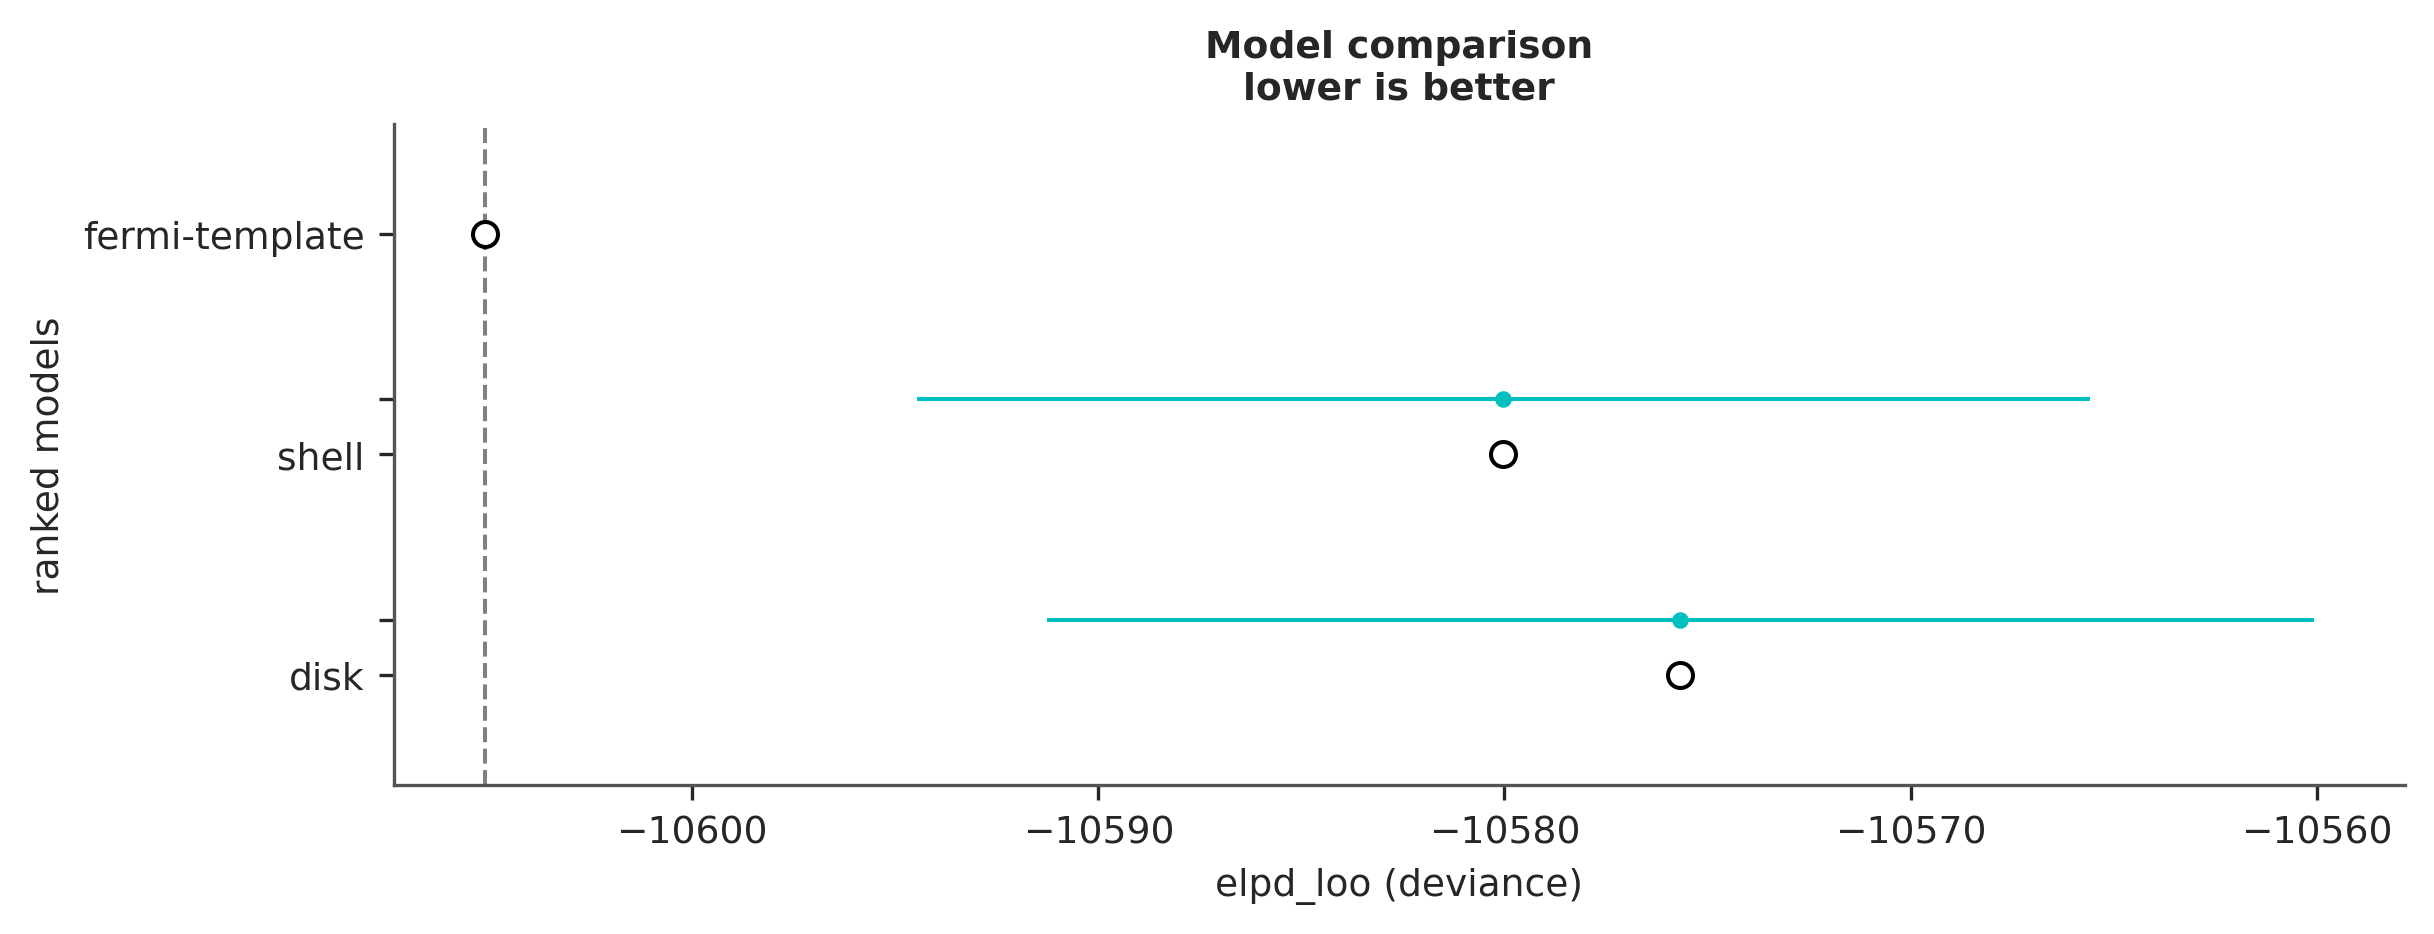

In [10]:
compare_3d = bms_results_3d.compare()
az.style.use("arviz-doc")
az.plot_compare(
    compare_3d,
    figsize=(8, 3),
    plot_standard_error=False,
    plot_ic_diff=True,
    plot_kwargs={"marker_dse": ".", "color_dse": "C1"},
)

In [11]:
compare_3d

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
fermi-template,0,-10605.099371,2.748886,0.000000,0.951305,674.340439,0.000000,False,deviance
shell,1,-10580.025787,9.642168,25.073583,0.031757,674.684368,14.430991,True,deviance
disk,2,-10575.667321,7.081832,29.432049,0.016939,674.548119,15.589350,True,deviance


We see there is a warning so we can look at the elpd_loo printout for details

In [12]:
bms_results_3d["shell"].elpd_loo

Computed from 835 posterior samples and 4000 observations log-likelihood matrix.

             Estimate       SE
deviance_loo -10580.03   678.81
p_loo            9.64        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.66]   (good)     3735   93.4%
   (0.66, 1]   (bad)        46    1.1%
   (1, Inf)   (very bad)  219    5.5%

The Pareto k is bad for some pixels in that case, we could inspect which one (missing function to go back from flatten space to 3d cube). 
Eventually we might have to perform the exact LOO for these pixels (or mask them ?).

## Prior sensitivity check

In [13]:
bms_results_3d.prior_sensitivity_table()

fermi-template


component,prior,likelihood,diagnosis
label,,,
amplitude,0.008,0.086,✓
alpha,0.002,0.080,✓
beta,0.001,0.089,✓


disk


component,prior,likelihood,diagnosis
label,,,
amplitude,0.008,0.084,✓
alpha,0.002,0.099,✓
beta,0.001,0.116,✓
lon_0,0.002,0.097,✓
lat_0,0.001,0.112,✓
r_0,0.004,0.125,✓


shell


component,prior,likelihood,diagnosis
label,,,
amplitude,0.010,0.109,✓
alpha,0.002,0.111,✓
beta,0.002,0.140,✓
lon_0,0.002,0.143,✓
lat_0,0.001,0.124,✓
r_0,0.004,0.144,✓
eta,0.003,0.140,✓
